# Exploratory Data Analysis: Wastewater Stage-Wise Water Quality

Goal: evaluate whether the raw dataset can support prediction of final overall CODt and CODs removal performance using influent and anaerobic effluent measurements.

The dataset has three sample stages per sampling date:

- `inf_*`: influent
- `ana_*`: anaerobic effluent
- `eff_*`: final effluent

Prediction target definitions used here:

- `final_CODt_removal_pct = (inf_CODt - eff_CODt) / inf_CODt * 100`
- `final_CODs_removal_pct = (inf_CODs - eff_CODs) / inf_CODs * 100`

For leakage-aware prediction, final effluent variables are excluded from model features because they are measured at or after the target outcome.


In [15]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 1. Load and Basic Structure


In [16]:
RAW_PATH = "water_quality_raw.csv"

df = pd.read_csv(RAW_PATH)
df["sampling_date"] = pd.to_datetime(df["sampling_date"], dayfirst=True)

numeric_cols = df.columns.drop("sampling_date")
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

df = df.sort_values("sampling_date").reset_index(drop=True)

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Date range: {df['sampling_date'].min().date()} to {df['sampling_date'].max().date()}")
df.head()


Rows: 27
Columns: 25
Date range: 2025-12-01 to 2026-04-27


,sampling_date,inf_pH,inf_cond,inf_CODt,inf_CODs,inf_MLSS,inf_MLVSS,inf_TKN,inf_NH4N,ana_pH,ana_cond,ana_CODt,ana_CODs,ana_MLSS,ana_MLVSS,ana_TKN,ana_NH4N,eff_pH,eff_cond,eff_CODt,eff_CODs,eff_MLSS,eff_MLVSS,eff_TKN,eff_NH4N
0,2025-12-01,NaN,NaN,2695,2152,308.00,276.00,112.00,25.00,NaN,NaN,652,150,500.00,467.00,141.00,100.00,NaN,NaN,180,145,4.00,4.00,13,6.00
1,2025-12-03,3.95,NaN,4772,4349,255.00,215.00,258.00,50.00,7.41,NaN,999,306,630.00,440.00,159.00,100.00,7.56,NaN,147,139,5.00,5.00,13,6.00
2,2025-12-05,4.48,NaN,3935,3531,450.00,385.00,197.00,44.00,7.20,NaN,997,326,670.00,500.00,148.00,92.00,7.53,NaN,114,105,6.00,0.00,12,1.00
3,2025-12-08,4.99,NaN,2402,2255,233.00,197.00,111.00,98.00,7.55,NaN,612,321,305.00,250.00,154.00,112.00,7.56,NaN,135,98,37.00,17.00,13,6.00
4,2025-12-10,NaN,NaN,2993,1712,290.00,195.00,64.00,15.00,NaN,NaN,940,354,393.00,273.00,149.00,103.00,NaN,NaN,119,85,12.00,0.00,16,8.00


In [17]:
stage_prefixes = ["inf", "ana", "eff"]
for prefix in stage_prefixes:
    cols = [c for c in df.columns if c.startswith(prefix + "_")]
    print(f"{prefix}: {len(cols)} columns -> {cols}")


inf: 8 columns -> ['inf_pH', 'inf_cond', 'inf_CODt', 'inf_CODs', 'inf_MLSS', 'inf_MLVSS', 'inf_TKN', 'inf_NH4N']
ana: 8 columns -> ['ana_pH', 'ana_cond', 'ana_CODt', 'ana_CODs', 'ana_MLSS', 'ana_MLVSS', 'ana_TKN', 'ana_NH4N']
eff: 8 columns -> ['eff_pH', 'eff_cond', 'eff_CODt', 'eff_CODs', 'eff_MLSS', 'eff_MLVSS', 'eff_TKN', 'eff_NH4N']


## 2. Missingness and Data Completeness


In [18]:
missing = (
    df.isna().sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda x: x["missing_count"] / len(df) * 100)
    .sort_values("missing_pct", ascending=False)
)
missing


,missing_count,missing_pct
ana_cond,12,44.44
eff_cond,12,44.44
inf_cond,11,40.74
ana_pH,9,33.33
eff_pH,9,33.33
inf_pH,8,29.63
inf_MLVSS,4,14.81
inf_MLSS,4,14.81
eff_MLSS,4,14.81
ana_MLVSS,4,14.81


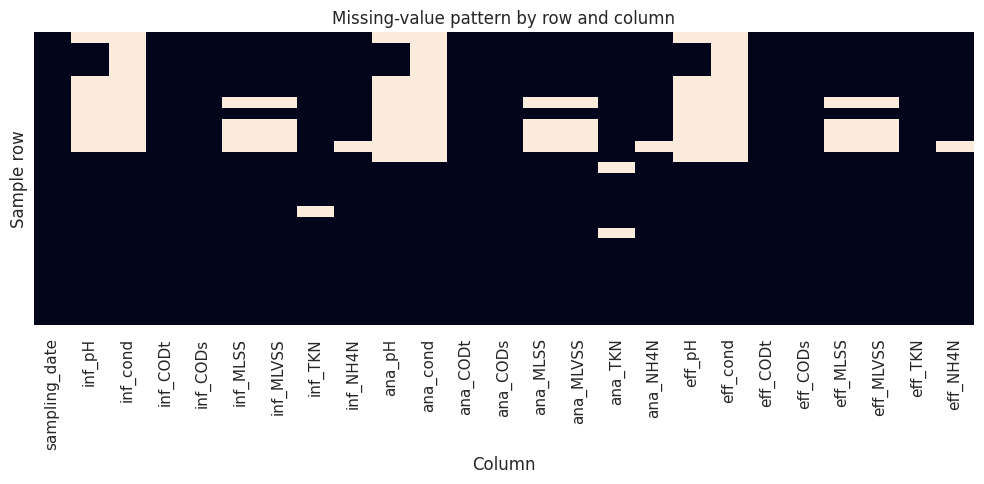

In [19]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, yticklabels=False)
plt.title("Missing-value pattern by row and column")
plt.xlabel("Column")
plt.ylabel("Sample row")
plt.tight_layout()
plt.show()


Key point for modeling: COD concentrations are complete, but pH and conductivity are missing in many early rows. With only 27 samples, dropping rows with any missing feature would discard too much information, so baseline models should use imputation.


## 3. Target Engineering: Final and Stage-Wise COD Removal


In [20]:
eda = df.copy()

eda["final_CODt_removal_pct"] = (eda["inf_CODt"] - eda["eff_CODt"]) / eda["inf_CODt"] * 100
eda["final_CODs_removal_pct"] = (eda["inf_CODs"] - eda["eff_CODs"]) / eda["inf_CODs"] * 100

eda["ana_CODt_removal_pct"] = (eda["inf_CODt"] - eda["ana_CODt"]) / eda["inf_CODt"] * 100
eda["ana_CODs_removal_pct"] = (eda["inf_CODs"] - eda["ana_CODs"]) / eda["inf_CODs"] * 100

eda["post_ana_CODt_removal_pct"] = (eda["ana_CODt"] - eda["eff_CODt"]) / eda["ana_CODt"] * 100
eda["post_ana_CODs_removal_pct"] = (eda["ana_CODs"] - eda["eff_CODs"]) / eda["ana_CODs"] * 100

target_cols = [
    "final_CODt_removal_pct", "final_CODs_removal_pct",
    "ana_CODt_removal_pct", "ana_CODs_removal_pct",
    "post_ana_CODt_removal_pct", "post_ana_CODs_removal_pct",
]
eda[target_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
final_CODt_removal_pct,27.00,93.81,4.59,80.22,92.48,96.02,97.01,97.69
final_CODs_removal_pct,27.00,93.66,3.43,84.78,91.87,94.42,96.80,97.56
ana_CODt_removal_pct,27.00,60.05,26.86,-26.41,57.35,68.59,77.49,85.71
ana_CODs_removal_pct,27.00,74.80,17.55,34.33,66.20,78.52,90.91,93.03
post_ana_CODt_removal_pct,27.00,83.44,8.72,47.04,81.37,84.64,87.63,93.61
post_ana_CODs_removal_pct,27.00,69.43,15.85,3.33,67.07,71.07,79.05,86.69


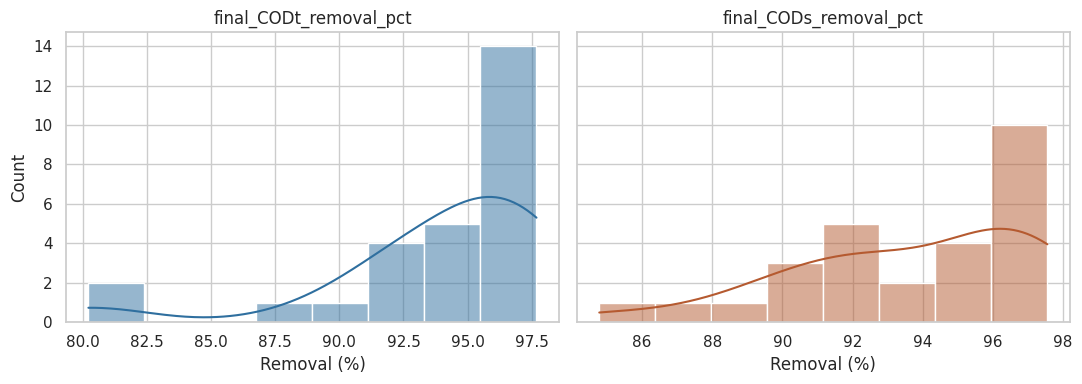

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, target, color in zip(
    axes,
    ["final_CODt_removal_pct", "final_CODs_removal_pct"],
    ["#2f6f9f", "#b55a30"],
):
    sns.histplot(eda[target], kde=True, ax=ax, color=color, bins=8)
    ax.set_title(target)
    ax.set_xlabel("Removal (%)")
plt.tight_layout()
plt.show()


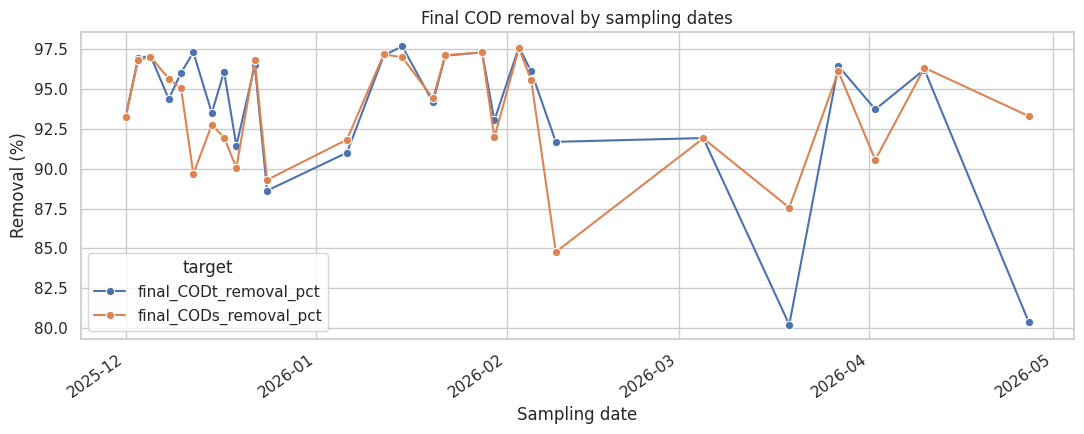

In [22]:
plot_df = eda[["sampling_date", "final_CODt_removal_pct", "final_CODs_removal_pct"]].melt(
    id_vars="sampling_date", var_name="target", value_name="removal_pct"
)

plt.figure(figsize=(11, 4.5))
sns.lineplot(data=plot_df, x="sampling_date", y="removal_pct", hue="target", marker="o")
plt.title("Final COD removal by sampling dates")
plt.xlabel("Sampling date")
plt.ylabel("Removal (%)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 4. Stage-Wise Concentration Profiles


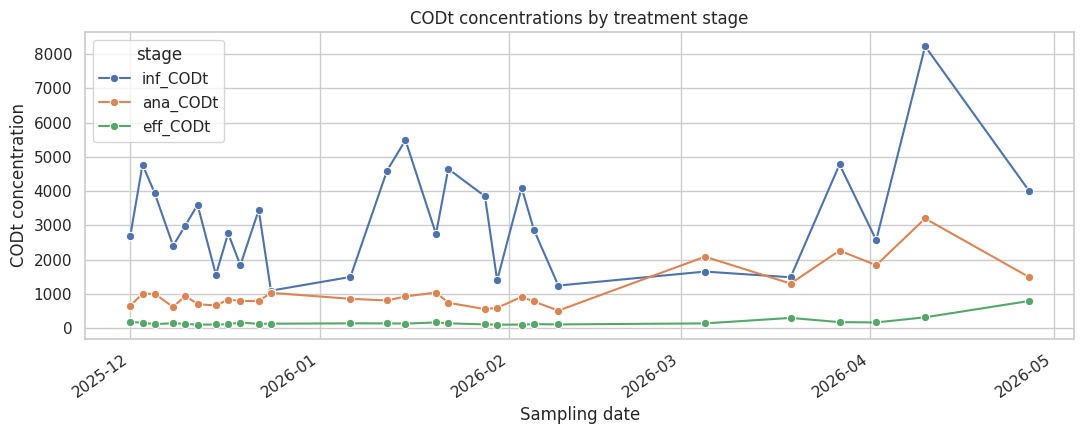

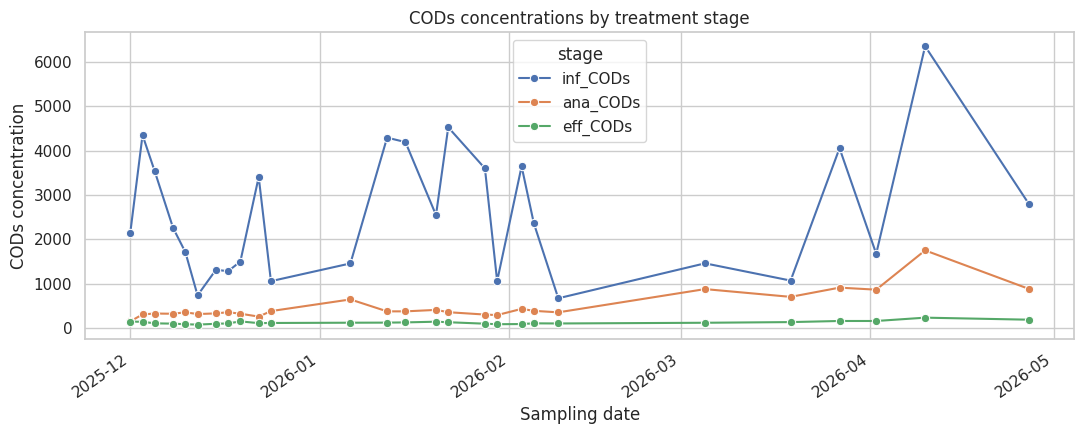

In [23]:
for analyte in ["CODt", "CODs"]:
    stage_cols = [f"inf_{analyte}", f"ana_{analyte}", f"eff_{analyte}"]
    long = eda[["sampling_date"] + stage_cols].melt(
        id_vars="sampling_date", var_name="stage", value_name=analyte
    )
    plt.figure(figsize=(11, 4.5))
    sns.lineplot(data=long, x="sampling_date", y=analyte, hue="stage", marker="o")
    plt.title(f"{analyte} concentrations by treatment stage")
    plt.xlabel("Sampling date")
    plt.ylabel(f"{analyte} concentration")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()


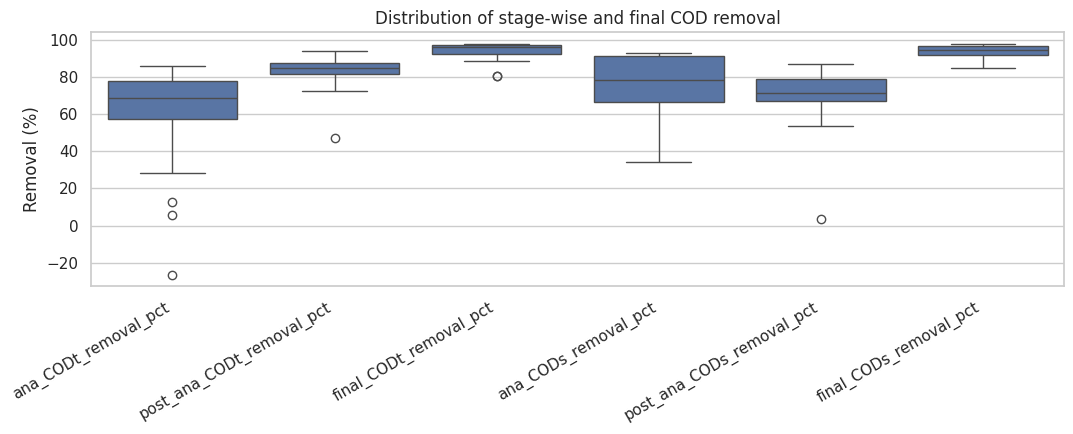

In [24]:
stage_removal = eda[[
    "ana_CODt_removal_pct", "post_ana_CODt_removal_pct", "final_CODt_removal_pct",
    "ana_CODs_removal_pct", "post_ana_CODs_removal_pct", "final_CODs_removal_pct",
]].melt(var_name="metric", value_name="removal_pct")

plt.figure(figsize=(11, 4.5))
sns.boxplot(data=stage_removal, x="metric", y="removal_pct")
plt.title("Distribution of stage-wise and final COD removal")
plt.xlabel("")
plt.ylabel("Removal (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 5. Leakage-Aware Feature Relationships


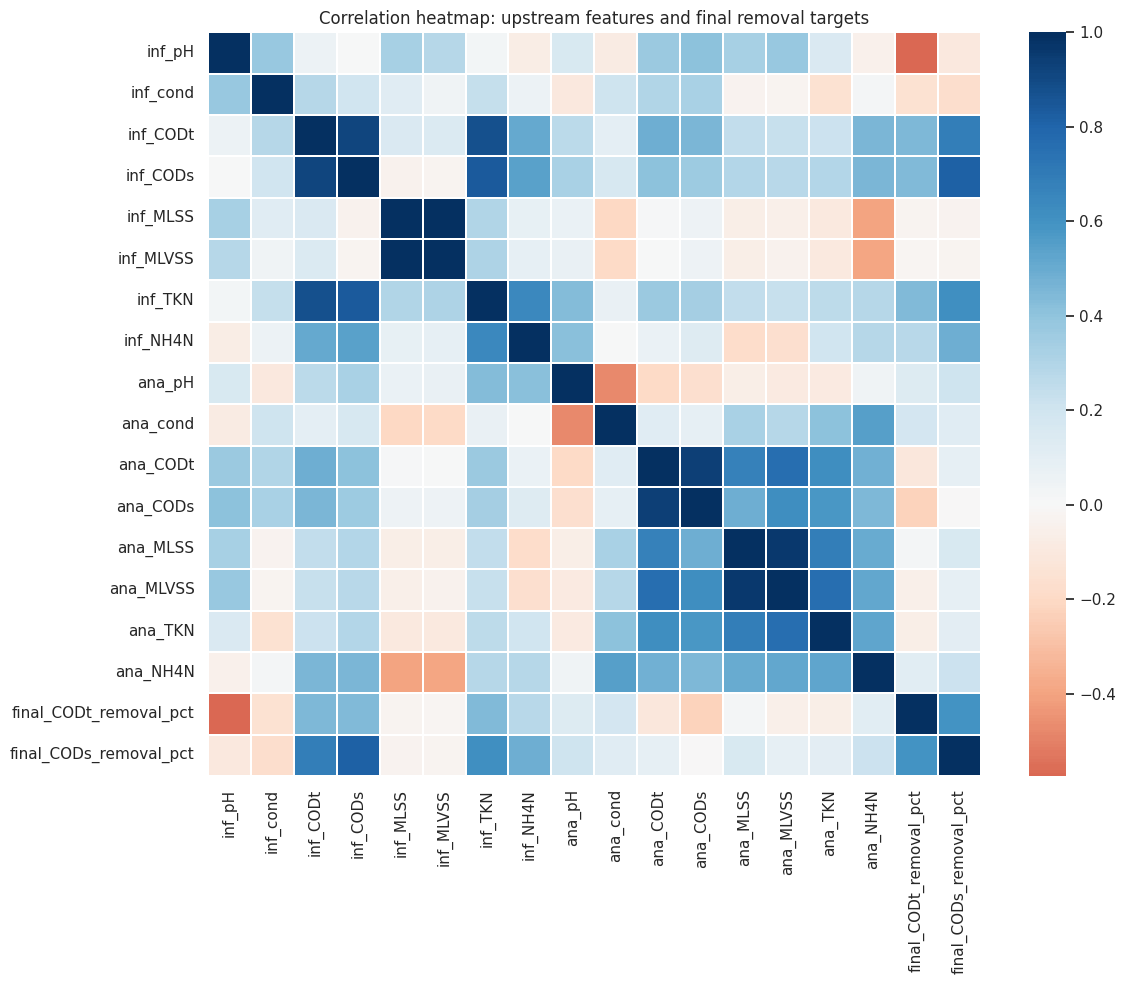

In [25]:
upstream_feature_cols = [
    c for c in eda.columns
    if (c.startswith("inf_") or c.startswith("ana_"))
    and c not in target_cols
]

corr_cols = upstream_feature_cols + ["final_CODt_removal_pct", "final_CODs_removal_pct"]
corr = eda[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="RdBu", center=0, linewidths=0.3)
plt.title("Correlation heatmap: upstream features and final removal targets")
plt.tight_layout()
plt.show()


In [26]:
for target in ["final_CODt_removal_pct", "final_CODs_removal_pct"]:
    print(f"Top absolute upstream correlations with {target}")
    display(
        corr[target]
        .drop(["final_CODt_removal_pct", "final_CODs_removal_pct"])
        .sort_values(key=lambda s: s.abs(), ascending=False)
        .to_frame("pearson_r")
        .head(10)
    )


Top absolute upstream correlations with final_CODt_removal_pct


,pearson_r
inf_pH,-0.57
inf_CODt,0.45
inf_TKN,0.44
inf_CODs,0.44
inf_NH4N,0.28
ana_CODs,-0.23
ana_cond,0.19
inf_cond,-0.15
ana_pH,0.14
ana_NH4N,0.11


Top absolute upstream correlations with final_CODs_removal_pct


,pearson_r
inf_CODs,0.81
inf_CODt,0.69
inf_TKN,0.61
inf_NH4N,0.48
ana_NH4N,0.22
ana_pH,0.20
inf_cond,-0.17
ana_MLSS,0.16
ana_cond,0.12
inf_pH,-0.10


This suggests CODs removal performance may be partly predictable from the incoming organic strength and how much removal already happens in the anaerobic stage

## 6. Baseline Prediction Feasibility


In [27]:
def evaluate_leave_one_out_model(X, y, model, label):
    mask = y.notna()
    X_eval = X.loc[mask]
    y_eval = y.loc[mask]

    preds = cross_val_predict(model, X_eval, y_eval, cv=LeaveOneOut())
    mae = mean_absolute_error(y_eval, preds)
    r2 = r2_score(y_eval, preds)
    baseline_mae = mean_absolute_error(y_eval, np.repeat(y_eval.mean(), len(y_eval)))

    return {
        "target": y.name,
        "model": label,
        "n_samples": len(y_eval),
        "mae_pct_points": mae,
        "mean_baseline_mae_pct_points": baseline_mae,
        "r2": r2,
    }

preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

ridge = Pipeline([
    ("preprocess", preprocess),
    ("model", RidgeCV(alphas=np.logspace(-3, 3, 25))),
])

rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=3,
        random_state=42,
    )),
])

feature_sets = {
    "influent_only": [c for c in upstream_feature_cols if c.startswith("inf_")],
    "influent_plus_anaerobic": upstream_feature_cols,
}

rows = []
for feature_set_name, features in feature_sets.items():
    X = eda[features]
    for target in ["final_CODt_removal_pct", "final_CODs_removal_pct"]:
        for model, label in [(ridge, "median_impute_scaled_ridge"), (rf, "median_impute_random_forest")]:
            result = evaluate_leave_one_out_model(X, eda[target], model, f"{feature_set_name}__{label}")
            rows.append(result)

model_results = pd.DataFrame(rows)
model_results.sort_values(["target", "mae_pct_points"])


,target,model,n_samples,mae_pct_points,mean_baseline_mae_pct_points,r2
3,final_CODs_removal_pct,influent_only__median_impute_random_forest,27,1.46,2.86,0.64
7,final_CODs_removal_pct,influent_plus_anaerobic__median_impute_random_...,27,1.48,2.86,0.63
6,final_CODs_removal_pct,influent_plus_anaerobic__median_impute_scaled_...,27,2.07,2.86,0.26
2,final_CODs_removal_pct,influent_only__median_impute_scaled_ridge,27,2.17,2.86,0.31
1,final_CODt_removal_pct,influent_only__median_impute_random_forest,27,2.53,3.19,0.07
5,final_CODt_removal_pct,influent_plus_anaerobic__median_impute_random_...,27,2.65,3.19,0.07
4,final_CODt_removal_pct,influent_plus_anaerobic__median_impute_scaled_...,27,3.19,3.19,-0.15
0,final_CODt_removal_pct,influent_only__median_impute_scaled_ridge,27,3.41,3.19,-0.43


Because the dataset has only 27 rows, these models are not production estimates. They are a sanity check: a useful model should beat the mean-removal baseline in leave-one-out validation and remain physically interpretable. If it does not, the current dataset may still be useful for descriptive process insight but weak for predictive deployment.


## 7. Practical Assessment


In [28]:
summary = {
    "n_samples": len(eda),
    "final_CODt_target_complete": int(eda["final_CODt_removal_pct"].notna().sum()),
    "final_CODs_target_complete": int(eda["final_CODs_removal_pct"].notna().sum()),
    "final_CODt_mean_pct": eda["final_CODt_removal_pct"].mean(),
    "final_CODt_sd_pct": eda["final_CODt_removal_pct"].std(),
    "final_CODs_mean_pct": eda["final_CODs_removal_pct"].mean(),
    "final_CODs_sd_pct": eda["final_CODs_removal_pct"].std(),
    "max_feature_missing_pct": df[upstream_feature_cols].isna().mean().max() * 100,
}
summary


{'n_samples': 27,
 'final_CODt_target_complete': 27,
 'final_CODs_target_complete': 27,
 'final_CODt_mean_pct': np.float64(93.81214690400283),
 'final_CODt_sd_pct': np.float64(4.586453816506911),
 'final_CODs_mean_pct': np.float64(93.65941615600708),
 'final_CODs_sd_pct': np.float64(3.42581805915996),
 'max_feature_missing_pct': np.float64(44.44444444444444)}

Initial conclusion:

- The raw dataset is suitable for EDA and target construction because influent, anaerobic effluent, and final effluent COD values are complete.
- It may support exploratory prediction of final CODt/CODs removal, but the sample size is currently very small for a reliable machine-learning model.
- A leakage-aware model should use influent and anaerobic effluent features only when predicting final removal. Final effluent COD values define the target, so they must not be used as predictors.
- CODs removal appears more variable with stronger upstream signal than CODt removal in this snapshot, but this needs validation as more samples are collected.
- Recommended next step: keep this EDA notebook as the baseline, then build a small reproducible modeling script/notebook with nested or leave-one-out validation, target-specific feature sets, and prediction intervals.
